<br>
<a href="https://www.nvidia.com/en-us/training/">
    <div style="width: 55%; background-color: white; margin-top: 50px;">
    <img src="https://dli-lms.s3.amazonaws.com/assets/general/nvidia-logo.png"
         width="400"
         height="186"
         style="margin: 0px -25px -5px; width: 300px"/>
    </div>
</a>
<h1 style="line-height: 1.4;"><font color="#76b900"><b>How to Run AI-Powered Computer-Aided Engineering Simulations</b></font></h1>
<h2><b>Appendix A:</b> OpenRadioss Bumper Beam: ML Surrogate Model Dataset Generator</h2>
<br>

## 🎯 Project Goal
This repository contains the pipeline to generate, simulate, and organize a high-fidelity synthetic dataset for training **Machine Learning (ML) Surrogate Models**. 

The specific use case is a **Bumper Beam Impact Simulation** running in **OpenRadioss**. By parameterizing the Finite Element Analysis (FEA) inputs (geometry, thickness, impact velocity, and impactor position), we generate hundreds of unique crash scenarios. The resulting dataset allows for the training of an FDA (Force-Displacement-Analysis) ML model circuit, enabling real-time prediction capabilities for laboratory customer demonstrations.

The base **Bumper Beam Impact Simulation** case generation is described here:

https://2021.help.altair.com/2021/hwdesktop/engsol/topics/solvers/rad/front_impact_bumper_hm_r.htm#front_impact_bumper_hm_r

And the OpenRadioss model files are fetched from here:

https://openradioss.atlassian.net/wiki/spaces/OPENRADIOSS/pages/11075585/Bumper+Beam

---

## ⚙️ Prerequisites

* **Python 3.8+**
* **OpenRadioss:** Installed and accessible.
* **Python Dependencies:** `vortex_radioss` (for D3PLOT conversion), `json`, `csv`, `shutil`.

---

## 🚀 Workflow Overview

The pipeline consists of two distinct stages:
1.  **Data Generation:** Parametrizing the mesh and input decks.
2.  **Batch Execution:** Running the FEA solver and converting results.

---

## 📂 Script 1: Dataset Generation
### `dataset_generation_bumper.py`

This script is responsible for creating the Design of Experiments (DoE). It reads a base Radioss simulation deck (`.rad` files), permutes the parameters defined in the experiment setup, and writes a unique folder for every run.

### 📥 Inputs
* **Base Starter File:** `Bumper_Beam_AP_meshed_0000.rad` (The mesh/node definitions).
* **Base Engine File:** `Bumper_Beam_AP_meshed_0001.rad` (The simulation control cards).
* **Parameter Ranges:** Defined in the `experiment_setup` dictionary within the script:
    * **Geometry Scale (X, Y, Z):** Stretches or shrinks the bumper dimensions.
    * **Thickness Scale:** Modifies the shell property thickness.
    * **Velocity Vector:** Changes the initial velocity of the impactor/beam.
    * **Rigid Wall (RWALL):** Modifies the impactor diameter and origin position.

### 📤 Outputs
* **Directory Structure:** Creates a `dataset/` folder containing sub-folders `run1/`, `run2/`, etc.
* **Modified Decks:** Inside each run folder, a modified `0000.rad` and a copy of `0001.rad`.
* **Metadata (Labels):**
    * `summary.json`: A full hierarchical log of all runs.
    * `summary.csv`: A flattened tabular file ideal for **ML Data Loading** (contains `Run_ID` mapped to input parameters).

### 📖 Usage

In [ ]:
!python dataset_generation_bumper.py

### 🧪 Default Experiment Setup

The script ships with a pre-configured Design of Experiments (DoE) that produces **135 unique simulation runs**. The default parameter space is:

| Parameter | Values | Count |
| :--- | :--- | :---: |
| **Geometry Scale (X, Y, Z)** | `(1.0, 1.0, 1.0)`, `(1.0, 0.5, 1.0)`, `(1.0, 1.0, 0.5)`, `(1.0, 2.0, 1.0)`, `(1.0, 1.0, 2.0)` | 5 |
| **Velocity (Vx, Vy, Vz)** | `(-5.0, 0, 0)`, `(-3.0, 0, 0)`, `(-7.0, 0, 0)` mm/ms | 3 |
| **Thickness Scale** | `1.0`, `0.7`, `1.3` | 3 |
| **Rigid Wall Diameter** | `254.0` mm | 1 |
| **Rigid Wall Origin (X, Y, Z)** | `(-170, 0, 0)`, `(-170, 120, 0)`, `(-170, 240, 0)` | 3 |

**Total Combinations:** 5 × 3 × 3 × 1 × 3 = **135 runs**

-----

## ⚡ Script 2: Simulation Runner

### `run_bumper.py`

This script acts as the High-Performance Computing (HPC) orchestrator. It iterates through the generated dataset folders and executes the OpenRadioss solver in parallel, managing CPU threads to optimize throughput.

### 📥 Inputs

  * **Target Directory:** The `dataset/` folder generated by the previous script.
  * **OpenRadioss Paths:** Path to `starter_linux64_gf`, `engine_linux64_gf`, and `anim_to_vtk_linux64_gf`.
  * **Resource Config:** `MAX_PARALLEL_JOBS` and `OMP_NUM_THREADS` (e.g., running 2 jobs at once with 8 threads each).

### 📤 Outputs

  * **Solver Logs:** `starter.log` and `engine.log` in each run folder.
  * **Animation Files:** The raw OpenRadioss `A001`, `A002`... files.
  * **Visualizations:**
      * `.vtk` files: Converted animation steps (viewable in Paraview).
      * `d3plot` files: Converted via the `vortex_radioss` library.

### ⚠️ Configuration Note

Before running `run_bumper.py`:
- Install [**`OpenRadioss`**](https://github.com/OpenRadioss/OpenRadioss) to simulate the scenes.
- Update the `OPENRADIOSS_ROOT` variable to match your local installation path.
- Install [**`VortexRadioss`**](https://github.com/Vortex-CAE/Vortex-Radioss.git) to help read in the Radioss files.

In [ ]:
# !rm -rf OpenRadioss
## Download and unzip OpenRadioss Binaries
![ ! -f OpenRadioss_linux64.zip ] && \
    wget https://github.com/OpenRadioss/OpenRadioss/releases/download/latest-20260120/OpenRadioss_linux64.zip
![ ! -d OpenRadioss ] && unzip -q OpenRadioss_linux64.zip

In [ ]:
!pip install -q lasso-python
!git clone https://github.com/Vortex-CAE/Vortex-Radioss.git
!cd Vortex-Radioss && pip install -e .

### 📖 Usage

In [ ]:
%%time
!OPENRADIOSS_ROOT=/dli/task/fea-dataset-gen-gtc-lab-main/OpenRadioss\
    python run_bumper.py

-----

## 🔄 Script 3: D3plot Renaming

### `d3plot_renaming.sh`

This utility script renames the generated D3PLOT files to match the naming convention expected by **PhysicsNeMo Curator**.

### Why is this needed?

OpenRadioss (via `vortex_radioss`) outputs animation files with the naming pattern:
```
Bumper_Beam_AP_meshed.d3plot
Bumper_Beam_AP_meshed.d3plot01
Bumper_Beam_AP_meshed.d3plot02
...
```

However, **PhysicsNeMo Curator** expects the standard LS-DYNA naming convention:
```
d3plot
d3plot01
d3plot02
...
```

### 📖 Usage

In [ ]:
!sh ./d3plot_renaming.sh

In [ ]:
# !du -h dataset/run1/
# !du -h dataset/run1/*

In [ ]:
# !apt-get install libgl1 vtk-osmesa -y

/usr/local/lib/python3.12/dist-packages/pyvista/plotting/utilities/xvfb.py:48: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk-osmesa instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


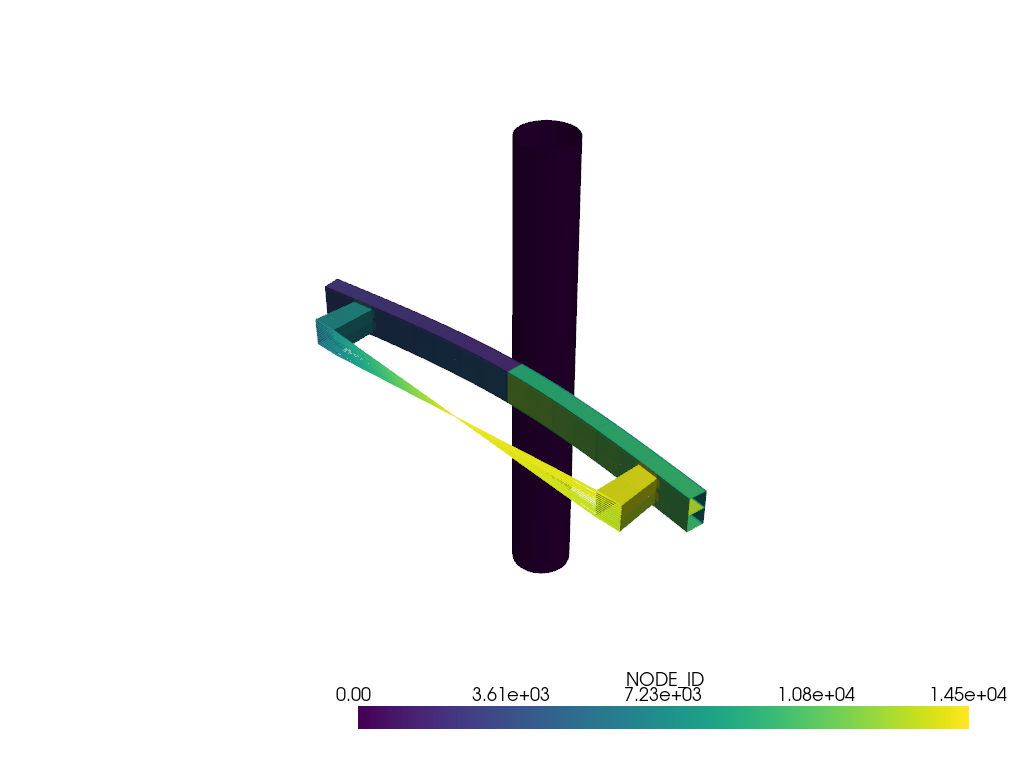

In [2]:
import pyvista as pv

pv.start_xvfb()   # safe even if xvfb isn't present

mesh = pv.read("dataset/run1/Bumper_Beam_AP_meshedA001.vtk")

plotter = pv.Plotter(off_screen=True)
plotter.add_mesh(mesh, show_edges=False)
plotter.camera_position = 'iso'

plotter.show(screenshot="frame_0001.png")

In [3]:
plotter = pv.Plotter(off_screen=True)
plotter.open_gif("deformation.gif")

for i in range(1, 52):
    mesh = pv.read(f"dataset/run1/Bumper_Beam_AP_meshedA{i:03d}.vtk")
    plotter.clear()
    plotter.add_mesh(mesh)
    plotter.write_frame()

plotter.close()

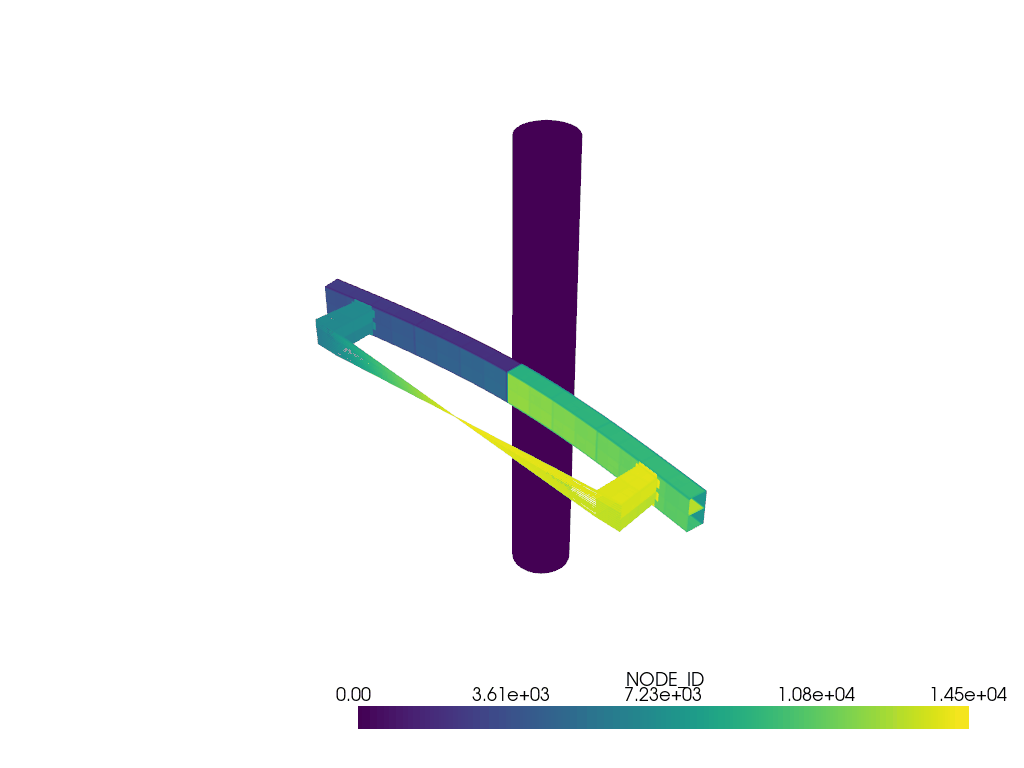

In [1]:
from IPython.display import Image
Image("deformation.gif")

> **Note:** Update the `BASE_DIR` variable inside the script to point to your `dataset/` folder before running.

-----

## 📊 Dataset Visualization

Below are examples of the data generated by this pipeline.

### 1\. Geometric Variations

*The following image demonstrates how the scaling parameters alter the bumper aspect ratio.*

*(Placeholder)*

### 2\. Impact Simulation (Paraview)

*A time-lapse of the bumper beam deformation under high-velocity impact.*

[GIF of Bumper Impact Animation]
*(Placeholder)*

-----

## 📝 Data Dictionary (Summary.csv)

The `summary.csv` file allows you to map input features to the simulation results.

| Column | Description | Unit |
| :--- | :--- | :--- |
| `Run_ID` | Unique identifier for the folder | String |
| `Geo_Scale_X/Y/Z` | Scaling factor applied to nodes | Float (Ratio) |
| `Vel_X/Y/Z` | Initial Velocity vector components | mm/ms |
| `Thickness_Factor` | Multiplier for shell thickness | Float (Ratio) |
| `Wall_X/Y/Z` | Origin coordinates of the rigid wall | Coordinates |

-----

## 💾 Dataset Location

The generated dataset has been placed on the **ORD Cluster** at:

```
/lustre/fs11/portfolios/coreai/users/phermosomore/datasets/RAW_FEA_DATASET/
```

-----